# DataLab-Kernel — Advanced Plotting Showcase

This notebook demonstrates the **interactive Plotly visualization** features of **DataLab-Kernel**.

Unlike the Quick Start notebook (which connects to a running DataLab instance),
this notebook works entirely in **standalone mode** — no DataLab GUI needed.
We create signals and images programmatically with [Sigima](https://sigima.readthedocs.io/)
and render them with the Plotly backend.

## Demonstrated features

- **Interactive Plotly backend** — zoom, pan, hover over every plot
- **Unified `plotter.plot()` API** — pass a single object or a list of signals/images
- **ROI visualization** — shaded regions on signals, rectangles/circles on images
- **Geometry & table result overlays** — FWHM segments, detected blobs, statistics
- **Curve styles** — Lines, Steps, Sticks, custom colors and dash patterns
- **Colormaps & LUT range** — control color mapping and contrast
- **Log scale, error bars, non-uniform coordinates**

## 1. Setup

### Import the extension

If you haven't already, run the following cell to load the `datalab_kernel` extension and import necessary libraries. You can skip re-importing libraries in subsequent cells. This will start the kernel in standalone mode, allowing you to run the notebook without a DataLab instance (it may take a few seconds to initialize because it first tries to connect to DataLab, then falls back to standalone mode when it fails).

In [3]:
%load_ext datalab_kernel

INFO:datalab-kernel:DataLab Kernel 0.2.10 started in standalone mode
INFO:datalab-kernel:DataLab extension loaded successfully


In [8]:
import numpy as np
import sigima.objects
import sigima.proc.image
import sigima.proc.signal

### Set the plotting backend (optional)

Choose one of the following lines to set either the Plotly or Matplotlib backend. The rest of the code is the same regardless of the backend. You may also skip this step and use the default Plotly backend.

> Note: the comments with `# type: ignore` and `# noqa: F821` hide unsightly warnings in the notebook editor, since the `plotter` variable is injected by the `datalab_kernel` extension, but they are absolutely *not necessary* for the code to run.

In [4]:
plotter.set_backend("matplotlib")  # type: ignore # noqa: F821

In [3]:
plotter.set_backend("plotly")  # type: ignore # noqa: F821

---
## 2. Rich Signal — All features combined

A single plot showcasing **error bars**, **ROI regions**, **axis bounds**,
**geometry overlays** (FWHM segment), and **statistics table** — all rendered
interactively.

C:\Dev\Outils\WPy64-31320\python\Lib\site-packages\sigima\tools\signal\pulse.py:1347: UserWarning: Multiple crossing points found. Returning first.
  warnings.warn("Multiple crossing points found. Returning first.")
C:\Dev\Outils\WPy64-31320\python\Lib\site-packages\sigima\tools\signal\pulse.py:1358: UserWarning: Multiple crossing points found. Returning last.
  warnings.warn("Multiple crossing points found. Returning last.")



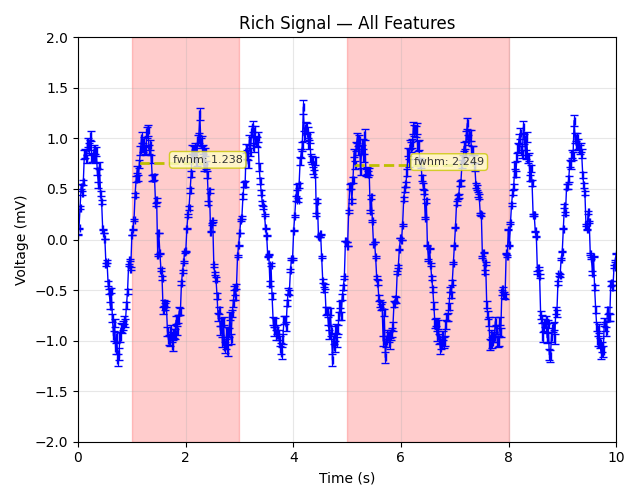

In [9]:
# Build a rich signal with every feature
np.random.seed(42)
n = 500
x = np.linspace(0, 10, n)
y = np.sin(2 * np.pi * x) + 0.1 * np.random.randn(n)
dx = np.full(n, 0.01)
dy = np.abs(y) * 0.05

sig_rich = sigima.objects.create_signal(
    title="Damped oscillation", x=x, y=y, dx=dx, dy=dy,
    labels=("Time", "Voltage"), units=("s", "mV"),
)
sig_rich.roi = sigima.objects.create_signal_roi([[1.0, 3.0], [5.0, 8.0]])
sig_rich.autoscale = False
sig_rich.xscalemin, sig_rich.xscalemax = 0.0, 10.0
sig_rich.yscalemin, sig_rich.yscalemax = -2.0, 2.0
sig_rich.set_metadata_option("shade", 0.2)

# Compute analysis results with Sigima and embed in metadata for overlay
fwhm_result = sigima.proc.signal.fwhm(sig_rich)
if fwhm_result is not None:
    sig_rich.metadata["Geometry_fwhm"] = fwhm_result.to_dict()

stats_result = sigima.proc.signal.stats(sig_rich)
sig_rich.metadata["Table_statistics"] = stats_result.to_dict()

plotter.plot(sig_rich, title="Rich Signal — All Features", show_roi=True)

---
## 3. Curve Styles — Lines, Steps, Sticks

DataLab-Kernel supports different curve rendering styles via metadata.
Compare them side by side:


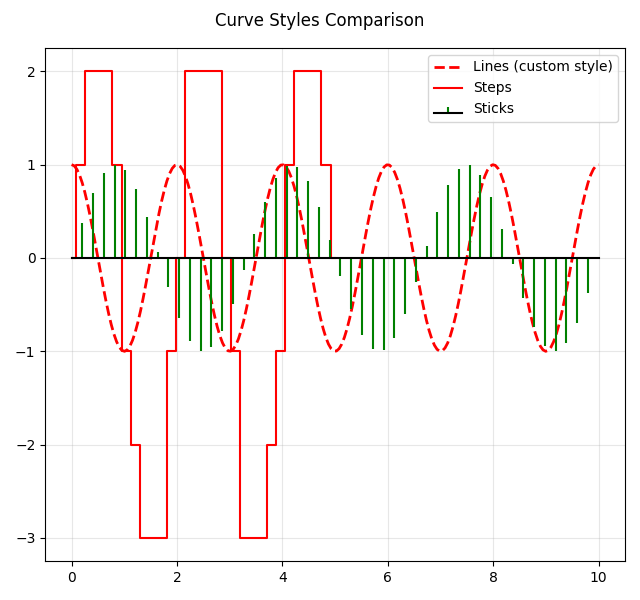

In [10]:
x_steps = np.linspace(0, 5, 30)
y_steps = np.floor(np.sin(2 * np.pi * 0.5 * x_steps) * 3)
sig_steps = sigima.objects.create_signal(title="Steps", x=x_steps, y=y_steps)
sig_steps.set_metadata_option("curvestyle", "Steps")

x_sticks = np.linspace(0, 10, 50)
y_sticks = np.sin(2 * np.pi * 0.3 * x_sticks)
sig_sticks = sigima.objects.create_signal(title="Sticks", x=x_sticks, y=y_sticks)
sig_sticks.set_metadata_option("curvestyle", "Sticks")

x_lines = np.linspace(0, 10, 200)
y_lines = np.cos(2 * np.pi * 0.5 * x_lines)
sig_lines = sigima.objects.create_signal(title="Lines (custom style)", x=x_lines, y=y_lines)
sig_lines.metadata["color"] = "red"
sig_lines.metadata["linestyle"] = "DashLine"
sig_lines.metadata["linewidth"] = 2

plotter.plot(
    [sig_lines, sig_steps, sig_sticks],
    title="Curve Styles Comparison",
)

---
## 4. Log Scale — Frequency response

Log-log plots are essential for frequency analysis. Both axes switch to
logarithmic scale automatically.

In [ ]:
x_log = np.logspace(0, 3, 200)
y_log = 1.0 / x_log
sig_log = sigima.objects.create_signal(
    title="Frequency response", x=x_log, y=y_log,
    labels=("Frequency", "Magnitude"), units=("Hz", "dB"),
)
sig_log.xscalelog = True
sig_log.yscalelog = True

plotter.plot(sig_log, title="Log-Log Scale")

---
## 5. Error Bars

Display measurement uncertainty with dx/dy error bars on a decaying
oscillation.

In [ ]:
x_eb = np.linspace(0, 10, 200)
y_eb = np.exp(-0.3 * x_eb) * np.sin(2 * np.pi * 0.5 * x_eb)
dx_eb = np.full_like(x_eb, 0.05)
dy_eb = np.abs(y_eb) * 0.15 + 0.02

sig_eb = sigima.objects.create_signal(
    title="Decaying oscillation", x=x_eb, y=y_eb, dx=dx_eb, dy=dy_eb,
    labels=("Frequency", "Power"), units=("Hz", "dB"),
)

plotter.plot(sig_eb, title="Signal with Error Bars")

PlotlyPlotResult(SignalObj: Signal with Error Bars)

---
## 6. Multi-Signal Overlay

Compare multiple signals on a single interactive plot. Supports
SignalObj, plain numpy arrays, and (x, y) tuples.

In [26]:
# Three sine waves at different frequencies
sigs = [
    sigima.objects.create_signal(
        title=f"f = {f} Hz",
        x=np.linspace(0, 10, 500),
        y=np.sin(2 * np.pi * f * np.linspace(0, 10, 500)),
        labels=("Time", "Amplitude"), units=("s", "V"),
    )
    for f in [0.5, 1.0, 1.5]
]
sigs[0].roi = sigima.objects.create_signal_roi([[1.0, 3.5], [6.0, 8.5]])

plotter.plot(sigs, title="Multi-Signal Overlay with ROI", show_roi=True)

---
## 7. Rich Image — ROIs, Colormap, LUT range, and Analysis

A 2D image with custom coordinates, colormap, contrast control (LUT range),
ROI overlays, and analysis results (centroid, statistics) computed by Sigima.


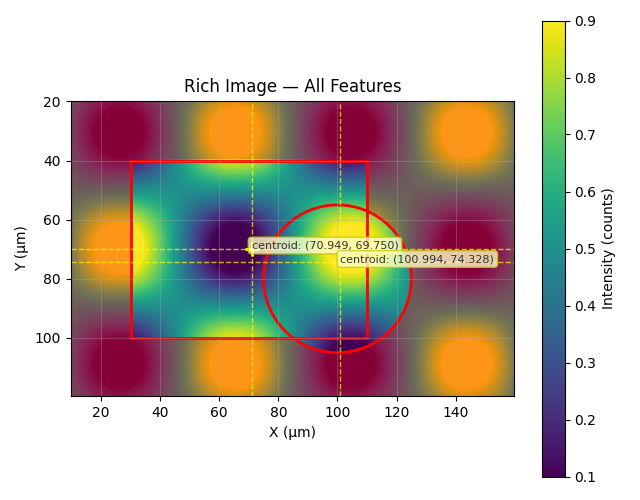

In [11]:
shape = (200, 300)
yc = np.linspace(-2, 2, shape[0])[:, np.newaxis]
xc = np.linspace(-2, 2, shape[1])[np.newaxis, :]
data = (np.sin(xc * 3) * np.cos(yc * 2) + 1).astype(np.float32) / 2

img_rich = sigima.objects.create_image(
    title="Interference pattern", data=data,
    labels=("X", "Y", "Intensity"), units=("µm", "µm", "counts"),
)
img_rich.set_uniform_coords(dx=0.5, dy=0.5, x0=10.0, y0=20.0)

# ROIs: rectangle and circle
roi = sigima.objects.ImageROI()
roi.add_roi(sigima.objects.RectangularROI([30.0, 40.0, 80.0, 60.0], indices=False, title="Region A"))
roi.add_roi(sigima.objects.CircularROI([100.0, 80.0, 25.0], indices=False, title="Spot"))
img_rich.roi = roi

# LUT range and colormap
img_rich.autoscale = False
img_rich.zscalemin = 0.1
img_rich.zscalemax = 0.9
img_rich.set_metadata_option("colormap", "viridis")

# Compute analysis results with Sigima and embed in metadata for overlay
centroid_result = sigima.proc.image.centroid(img_rich)
if centroid_result is not None:
    img_rich.metadata["Geometry_centroid"] = centroid_result.to_dict()

stats_result = sigima.proc.image.stats(img_rich)
img_rich.metadata["Table_statistics"] = stats_result.to_dict()

plotter.plot(img_rich, title="Rich Image — All Features", show_roi=True)

---
## 8. Colormaps — Side by side comparison

Compare the same pattern rendered with different colormaps in a multi-image grid.


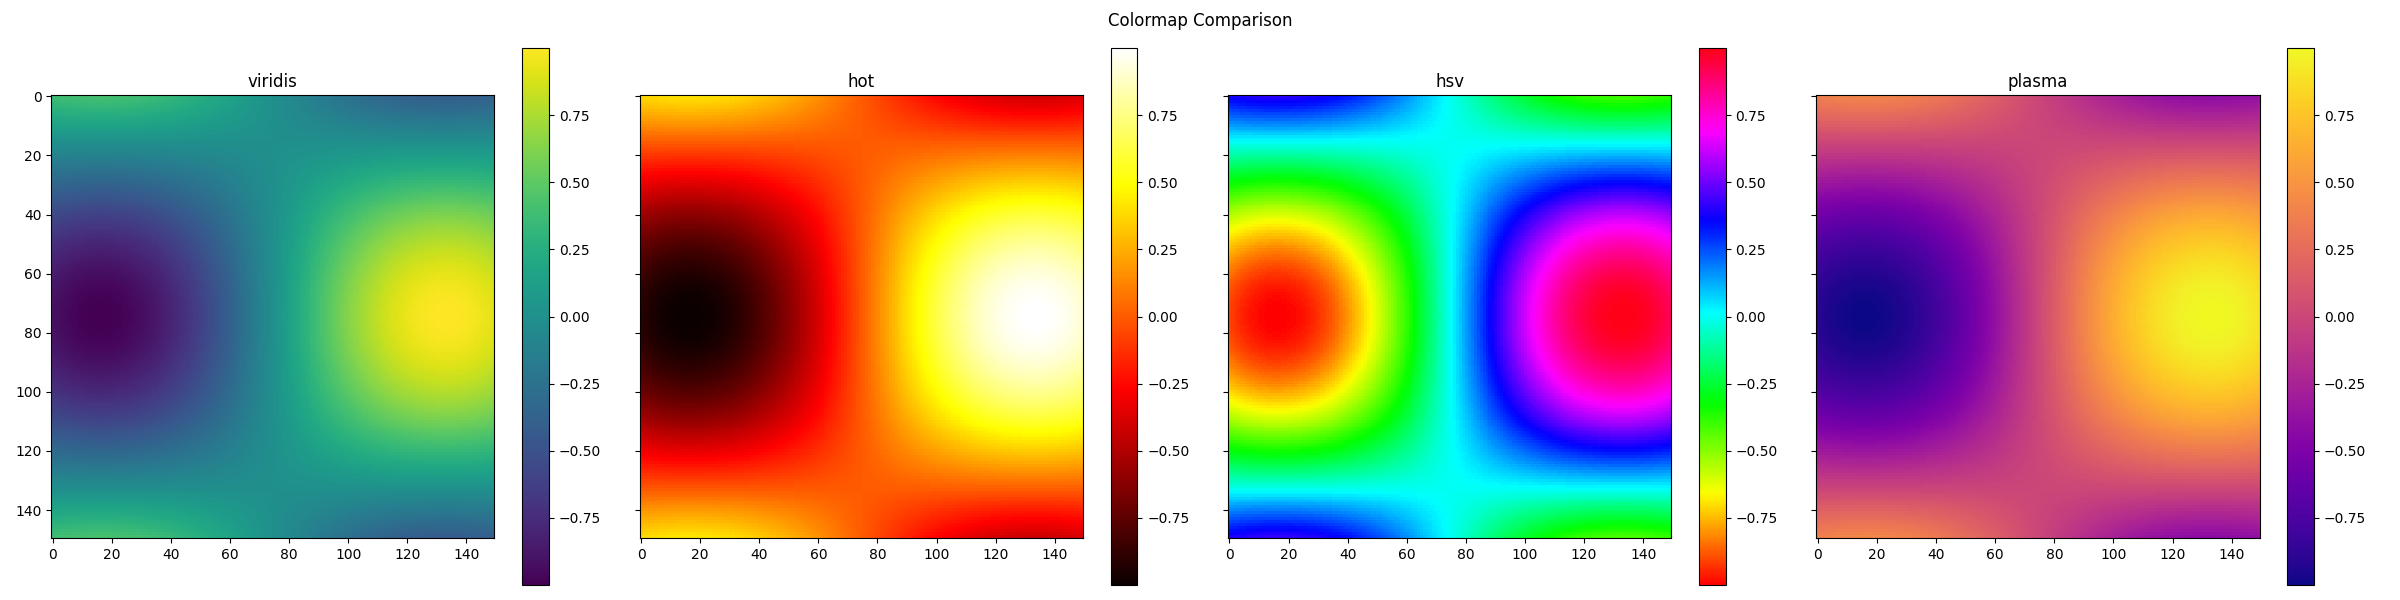

In [12]:
def make_colormap_image(cmap: str):
    """Create a 2D pattern with a given colormap."""
    shape = (150, 150)
    yc = np.linspace(-2, 2, shape[0])[:, np.newaxis]
    xc = np.linspace(-2, 2, shape[1])[np.newaxis, :]
    data = np.sin(xc) * np.cos(yc)
    img = sigima.objects.create_image(title=cmap, data=data.astype(np.float32))
    img.set_metadata_option("colormap", cmap)
    return img

colormaps = ["viridis", "hot", "hsv", "plasma"]
imgs_cmap = [make_colormap_image(c) for c in colormaps]

plotter.plot(imgs_cmap, title="Colormap Comparison", titles=colormaps)

---
## 9. Non-Uniform Image Coordinates

Images with logarithmic or irregular coordinate spacing are rendered correctly.

In [ ]:
shape_nu = (50, 80)
data_nu = np.random.rand(*shape_nu).astype(np.float32)
img_nu = sigima.objects.create_image(title="Non-uniform coordinates", data=data_nu)
xcoords = np.logspace(0, 2, shape_nu[1])   # Log-spaced X
ycoords = np.linspace(0, 10, shape_nu[0])   # Linear Y
img_nu.set_coords(xcoords, ycoords)

plotter.plot(img_nu, title="Image with Non-Uniform Coordinates")

PlotlyPlotResult(ImageObj: Image with Non-Uniform Coordinates)

---
## 10. Multi-Image with Geometry Overlays

Overlay geometry results (enclosing circle computed by Sigima) on an image grid.


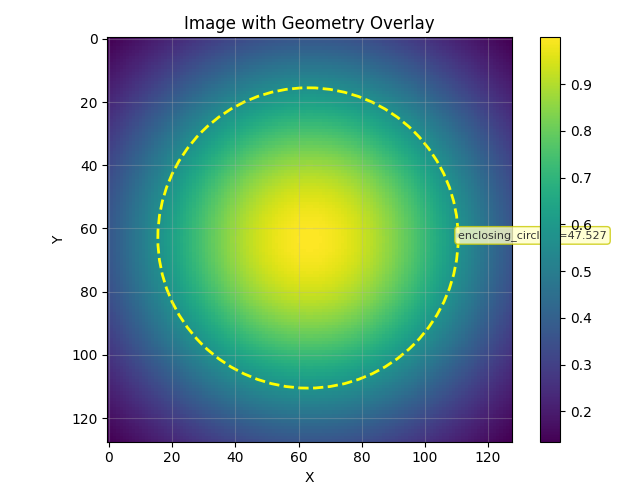

,Value
x,63
y,63
r,47.5


In [13]:
# Gaussian spot image
shape_g = (128, 128)
yg = np.linspace(-1, 1, shape_g[0])[:, np.newaxis]
xg = np.linspace(-1, 1, shape_g[1])[np.newaxis, :]
data_g = np.exp(-(xg**2 + yg**2)).astype(np.float32)
img_gauss = sigima.objects.create_image(title="Gaussian spot", data=data_g)

# Compute enclosing circle with Sigima
circle_result = sigima.proc.image.enclosing_circle(img_gauss)

plotter.plot(
    img_gauss, title="Image with Geometry Overlay",
    results=[circle_result],
)

---
## 11. Sigima Processing Pipeline

Combine Sigima processing with Plotly visualization. Process a signal through
a filter pipeline and compare before/after.


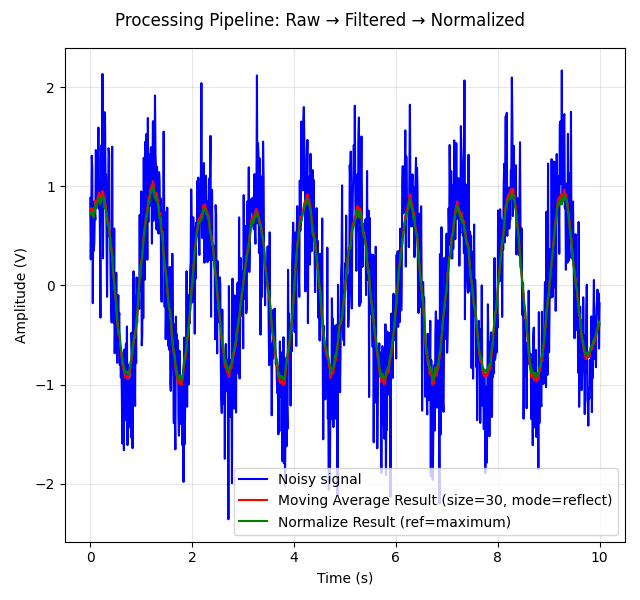

In [14]:
# Create a noisy signal
np.random.seed(0)
x_proc = np.linspace(0, 10, 1000)
y_proc = np.sin(2 * np.pi * x_proc) + 0.5 * np.random.randn(1000)
sig_noisy = sigima.objects.create_signal(
    title="Noisy signal", x=x_proc, y=y_proc,
    labels=("Time", "Amplitude"), units=("s", "V"),
)

# Apply moving average filter, then normalize
sig_filtered = sigima.proc.signal.moving_average(sig_noisy, n=30)
sig_norm = sigima.proc.signal.normalize(sig_filtered)

plotter.plot(
    [sig_noisy, sig_filtered, sig_norm],
    title="Processing Pipeline: Raw → Filtered → Normalized",
)

---
## 12. Analysis Results Display

Table and geometry results render as rich HTML tables — useful for
reporting statistics, FWHM measurements, or detection results.

In [32]:
# Compute statistics on the noisy signal from section 11
stats_result = sigima.proc.signal.stats(sig_noisy)
plotter.display_table(stats_result)

,Value
min,-2.36
max,2.17
mean,-0.0226
median,-0.0455
std,0.882
snr,-0.0257
ptp,4.53
sum,-22.6
trapz,-0.23


In [33]:
# Compute centroid of the Gaussian spot image from section 10
centroid_result = sigima.proc.image.centroid(img_gauss)
plotter.display_geometry(centroid_result)

,Value
x,63.5
y,63.5


---

**Tip:** All Plotly plots are fully interactive — hover for values, zoom with
the scroll wheel, click-drag to select a region, and double-click to reset
the view.